In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
 
import math
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from tqdm.notebook import tqdm
from syn2real_dataset import Syn2RealDataset
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml
import numpy as np
import math
import os

# Add ../ as a directory to import from
import sys
sys.path.append('../')

In [19]:
from models.plightning import  MainDataModule

dataset_dir = "../data/Sideview_Dec04_2024"
datamodule = MainDataModule(dataset_dir,
                            image_size=224,
                            load_depth=False,
                            train_batch_size=32, num_workers=1, process_leaf=False, preload=False, side_view=True)
datamodule.setup()

Total 140 images and plant strings loaded
Total 60 images and plant strings loaded
Total 100 images and plant strings loaded


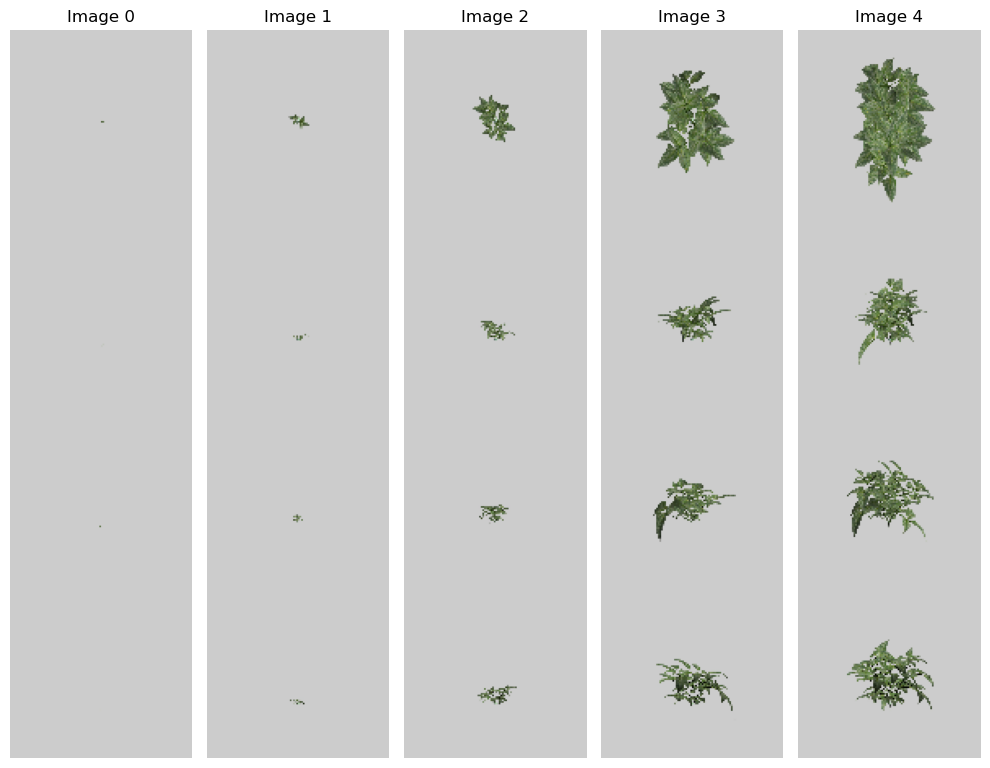

In [20]:
# Show some images
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import cv2

test_dataloader = datamodule.test_dataloader(shuffle=False)
test_dataset = test_dataloader.dataset

# Plot the images
plt.figure(figsize=(10, 20))  # Adjust the figure size for vertical layout
n = 5
for i in range(n):
    image, _, vecs, _ = test_dataset[4*i]
    image = image.permute(1, 2, 0)
    image_rgb = image[:, :, :3]
    if 0:
        img = cv2.normalize(np.array(image_rgb.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    else:
        img = np.array(image_rgb.cpu())
    
    
    # Split the 4-part image into 4 separate images
    img_size = img.shape[0] // 2
    img1 = img[:img_size, :img_size]
    img2 = img[:img_size, img_size:]
    img3 = img[img_size:, :img_size]
    img4 = img[img_size:, img_size:]
    
    # Combine the 4-part images into a single image
    combined_img = np.vstack((img1, img2,img3, img4))
    
    # Plot the combined image
    plt.subplot(1, n, i+1)
    plt.imshow(combined_img, vmax=255, vmin=0)
    plt.title(f"Image {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
dataset_dir = "../data/Sideview_Dec04_2024"
datamodule = MainDataModule(dataset_dir,
                            image_size=224,
                            load_depth=False,
                            train_batch_size=32, num_workers=1, process_leaf=True, preload=False, side_view=True)
datamodule.setup()
test_dataloader = datamodule.test_dataloader(shuffle=False)
test_dataset = test_dataloader.dataset
for i in range(n):
    image, _, vecs, _ = test_dataset[4*i]
    image = image.permute(1, 2, 0)
    image_rgb = image[:, :, :3]
    if 0:
        img = cv2.normalize(np.array(image_rgb.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    else:
        img = np.array(image_rgb.cpu())
    
    # Plot the combined image
    plt.subplot(1, n, i+1)
    plt.imshow(img, vmax=255, vmin=0)
    plt.title(f"Image {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [21]:
import xml.etree.ElementTree as ET
from string_to_xml_to_vec import xml2vec, pretty_print_xml, linked_to_recursive
from plant_tokenizer import vec2token
# Load Test Data
xml_file = "GenerateDataset/build_release/paper_example_nested_auxbud.xml"
tree = ET.parse(xml_file)
root = tree.getroot()
root = linked_to_recursive(root)
plant_array = []
for plant_instance in root:
    plant_instance_array = []
    xml2vec(plant_instance, plant_instance_array)
    plant_array.append(plant_instance_array)

In [ ]:
# print(plant_array[0])
two_digit_codes = [f"{x[0]:1d}{x[1]}" for x in plant_array[0]]
print(two_digit_codes)

[[0, 0, 0.0, 0.0, 90.0, 100.0, 1], [0, 1, 0.002, 0.0001, 0.0, 151.438], [0, 2, 0.00026, 0.000104, 73.0784, -137.6, 1.0], [0, 3, 0.0026, 4.02381, 0.0, -15.0], [1, 0, 0.0, 0.0, 0.0, 0, 3], [1, 1, 0.001, 0.0001, 5.0, 0.0], [1, 2, 0.00277791, 4.26521e-05, 70.4745, -100.0, 0.9], [1, 3, 0.00242547, -3.6003, 10.0, -15.0], [1, 4, 0.00269497, 7.42458, 0.0, -15.0], [1, 5, 0.00242547, 3.96681, -10.0, -15.0], [2, 0, 30.0, 0.0, 0.0, 0, 3], [2, 1, 0.0005, 5e-05, 0.0, 0.0], [2, 2, 0.000277791, 4.26521e-05, 0.0, -100.0, 0.9], [2, 3, 0.0005, -3.6003, 10.0, -15.0], [2, 4, 0.0005, 7.42458, 0.0, -15.0], [2, 5, 0.0005, 3.96681, -10.0, -15.0], [1, 1, 0.001, 0.0001, 0.0, 180.0], [1, 2, 0.00277791, 4.26521e-05, 45.0, -100.0, 0.9], [1, 3, 0.00242547, -3.6003, 10.0, -15.0], [1, 4, 0.00269497, 7.42458, 0.0, -15.0], [1, 5, 0.00242547, 3.96681, -10.0, -15.0], [1, 1, 0.001, 0.0001, -10.0, 180.0], [1, 2, 0.00277791, 4.26521e-05, 54.4745, -100.0, 0.9], [1, 3, 0.00242547, -3.6003, 10.0, -15.0], [1, 4, 0.00269497, 7.42

In [28]:
for line in plant_array[0]:
    print(line)

[0, 0, 0.0, 0.0, 90.0, 100.0, 1]
[0, 1, 0.002, 0.0001, 0.0, 151.438]
[0, 2, 0.00026, 0.000104, 73.0784, -137.6, 1.0]
[0, 3, 0.0026, 4.02381, 0.0, -15.0]
[1, 0, 0.0, 0.0, 0.0, 0, 3]
[1, 1, 0.001, 0.0001, 5.0, 0.0]
[1, 2, 0.00277791, 4.26521e-05, 70.4745, -100.0, 0.9]
[1, 3, 0.00242547, -3.6003, 10.0, -15.0]
[1, 4, 0.00269497, 7.42458, 0.0, -15.0]
[1, 5, 0.00242547, 3.96681, -10.0, -15.0]
[2, 0, 30.0, 0.0, 0.0, 0, 3]
[2, 1, 0.0005, 5e-05, 0.0, 0.0]
[2, 2, 0.000277791, 4.26521e-05, 0.0, -100.0, 0.9]
[2, 3, 0.0005, -3.6003, 10.0, -15.0]
[2, 4, 0.0005, 7.42458, 0.0, -15.0]
[2, 5, 0.0005, 3.96681, -10.0, -15.0]
[1, 1, 0.001, 0.0001, 0.0, 180.0]
[1, 2, 0.00277791, 4.26521e-05, 45.0, -100.0, 0.9]
[1, 3, 0.00242547, -3.6003, 10.0, -15.0]
[1, 4, 0.00269497, 7.42458, 0.0, -15.0]
[1, 5, 0.00242547, 3.96681, -10.0, -15.0]
[1, 1, 0.001, 0.0001, -10.0, 180.0]
[1, 2, 0.00277791, 4.26521e-05, 54.4745, -100.0, 0.9]
[1, 3, 0.00242547, -3.6003, 10.0, -15.0]
[1, 4, 0.00269497, 7.42458, 0.0, -15.0]
[1, 5, 0

In [34]:
from plant_tokenizer import vec2token
tokens = vec2token(plant_array[0])
np.set_printoptions(suppress=True)
print(tokens.tolist())

[[0.0, 0.0, 0.0, 90.0, 100.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.002, 0.0001, 0.0, 151.438, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00026, 0.000104, 73.0784, -137.6, 1.0, 0.0, 0.0, 0.0, 0.0], [3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0026, 4.02381, 0.0, -15.0], [6.0, 0.0, 0.0, 0.0, 0.0, 3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [7.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.001, 0.0001, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00277791, 4.26521e-05, 70.4745, -100.0, 0.9, 0.0, 0.0, 0.0, 0.0], [9.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00242547, -3.6003, 10.0, -15.0], [10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00269497, 7.42458, 0.0, -15.0], [11.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

In [35]:
len(tokens[0])

19

In [24]:
print((tokens[:,0]))

[ 0.  1.  2.  3.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.  7.  8.
  9. 10. 11.  7.  8.  9. 10. 11.  7.  8.  9. 10. 11.  7.  8.  9. 10. 11.
  2.  3.]


In [25]:
int_tokens = [int(x) for x in tokens[:,0]]
print(int_tokens)
print(len(int_tokens))

[0, 1, 2, 3, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 7, 8, 9, 10, 11, 7, 8, 9, 10, 11, 7, 8, 9, 10, 11, 7, 8, 9, 10, 11, 2, 3]
38


In [12]:
# Read XML file and tokenize it using transformers tokenizer
from transformers import AutoTokenizer

# Path to the XML file
xml_file = "GenerateDataset/build_release/paper_example_nested_auxbud.xml"

# Read the XML file as a text file
with open(xml_file, 'r', encoding='utf-8') as file:
    xml_content = file.read()

# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize the text content
tokens = tokenizer.tokenize(xml_content)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

# Print the tokens and token IDs
print("Tokens:", tokens)
print("Token IDs:", token_ids)

Token indices sequence length is longer than the specified maximum sequence length for this model (3204 > 512). Running this sequence through the model will result in indexing errors


Tokens: ['<', '?', 'xml', 'version', '=', '"', '1', '.', '0', '"', 'encoding', '=', '"', 'ut', '##f', '-', '8', '"', '?', '>', '<', 'he', '##lio', '##s', '>', '<', 'plant', '_', 'instance', 'id', '=', '"', '0', '"', '>', '<', 'base', '_', 'position', '>', '0', '0', '0', '<', '/', 'base', '_', 'position', '>', '<', 'plant', '_', 'age', '>', '100', '<', '/', 'plant', '_', 'age', '>', '<', 'shoot', 'id', '=', '"', '0', '"', '>', '<', 'shoot', '_', 'type', '_', 'label', '>', 'un', '##ifolia', '##te', '<', '/', 'shoot', '_', 'type', '_', 'label', '>', '<', 'parent', '_', 'shoot', '_', 'id', '>', '-', '1', '<', '/', 'parent', '_', 'shoot', '_', 'id', '>', '<', 'parent', '_', 'node', '_', 'index', '>', '0', '<', '/', 'parent', '_', 'node', '_', 'index', '>', '<', 'parent', '_', 'pet', '##iol', '##e', '_', 'index', '>', '0', '<', '/', 'parent', '_', 'pet', '##iol', '##e', '_', 'index', '>', '<', 'base', '_', 'rotation', '>', '0', '0', '90', '<', '/', 'base', '_', 'rotation', '>', '<', 'ph', '#

In [16]:
from transformers import AutoTokenizer

# Path to the XML file
xml_file = "GenerateDataset/build_release/paper_example_nested_auxbud.xml"

# Read the XML file as a text file
with open(xml_file, 'r', encoding='utf-8') as file:
    xml_content = file.read()

# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize the text content
tokens = tokenizer.tokenize(xml_content)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

# Decode the token IDs back to text
decoded_text = tokenizer.decode(token_ids)

# Remove unnecessary spaces
# decoded_text = decoded_text.replace(" ", "").replace(">", "> ").replace("<", " <").strip()


# Print the tokens and token IDs
print("Tokens:", tokens)
print("Token IDs:", token_ids)

# Print the original and decoded text for comparison
print("\nOriginal Text:\n", xml_content)
print("\nDecoded Text:\n", decoded_text)

# Compare the original and decoded text
if xml_content.strip() == decoded_text.strip():
    print("\nThe original and decoded text are identical.")
else:
    print("\nThe original and decoded text are different.")

Token indices sequence length is longer than the specified maximum sequence length for this model (3204 > 512). Running this sequence through the model will result in indexing errors


Tokens: ['<', '?', 'xml', 'version', '=', '"', '1', '.', '0', '"', 'encoding', '=', '"', 'ut', '##f', '-', '8', '"', '?', '>', '<', 'he', '##lio', '##s', '>', '<', 'plant', '_', 'instance', 'id', '=', '"', '0', '"', '>', '<', 'base', '_', 'position', '>', '0', '0', '0', '<', '/', 'base', '_', 'position', '>', '<', 'plant', '_', 'age', '>', '100', '<', '/', 'plant', '_', 'age', '>', '<', 'shoot', 'id', '=', '"', '0', '"', '>', '<', 'shoot', '_', 'type', '_', 'label', '>', 'un', '##ifolia', '##te', '<', '/', 'shoot', '_', 'type', '_', 'label', '>', '<', 'parent', '_', 'shoot', '_', 'id', '>', '-', '1', '<', '/', 'parent', '_', 'shoot', '_', 'id', '>', '<', 'parent', '_', 'node', '_', 'index', '>', '0', '<', '/', 'parent', '_', 'node', '_', 'index', '>', '<', 'parent', '_', 'pet', '##iol', '##e', '_', 'index', '>', '0', '<', '/', 'parent', '_', 'pet', '##iol', '##e', '_', 'index', '>', '<', 'base', '_', 'rotation', '>', '0', '0', '90', '<', '/', 'base', '_', 'rotation', '>', '<', 'ph', '#

In [29]:
print("\nOriginal Text:\n", xml_content)


Original Text:
 <?xml version="1.0" encoding="UTF-8"?>
<helios>
	<plant_instance ID="0">
		<base_position> 0 0 0 </base_position>
		<plant_age> 100 </plant_age>
		<shoot ID="0">
			<shoot_type_label> unifoliate </shoot_type_label>
			<parent_shoot_ID> -1 </parent_shoot_ID>
			<parent_node_index> 0 </parent_node_index>
			<parent_petiole_index> 0 </parent_petiole_index>
			<base_rotation> 0 0 90 </base_rotation>
			<phytomer>
				<internode>
					<internode_length>0.0020</internode_length>
					<internode_radius>0.0001</internode_radius>
					<internode_pitch>0</internode_pitch>
					<internode_phyllotactic_angle>151.438</internode_phyllotactic_angle>
					<petiole>
						<petiole_length>0.00026</petiole_length>
						<petiole_radius>0.000104</petiole_radius>
						<petiole_pitch>73.0784</petiole_pitch>
						<petiole_curvature>-137.6</petiole_curvature>
						<leaflet_scale>1</leaflet_scale>
						<leaf>
							<leaf_scale>0.0026</leaf_scale>
							<leaf_pitch>4.02381</leaf_pitch>
		